In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
train_size=0.67
cv_split=3
randomState=42
np.random.seed(42)

In [3]:
url = '../data/churn-analysis.csv'
df = pd.read_csv(url)
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,42,2,0.00,1,1,1,101348.88,True
1,502,0,42,8,159660.80,3,1,0,113931.57,True
2,699,0,39,1,0.00,2,0,0,93826.63,False
3,822,1,50,7,0.00,2,1,1,10062.80,False
4,501,1,44,4,142051.07,2,0,1,74940.50,False


array([[<Axes: title={'center': 'CreditScore'}>,
        <Axes: title={'center': 'Gender'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Tenure'}>,
        <Axes: title={'center': 'Balance'}>,
        <Axes: title={'center': 'NumOfProducts'}>],
       [<Axes: title={'center': 'HasCrCard'}>,
        <Axes: title={'center': 'IsActiveMember'}>,
        <Axes: title={'center': 'EstimatedSalary'}>]], dtype=object)

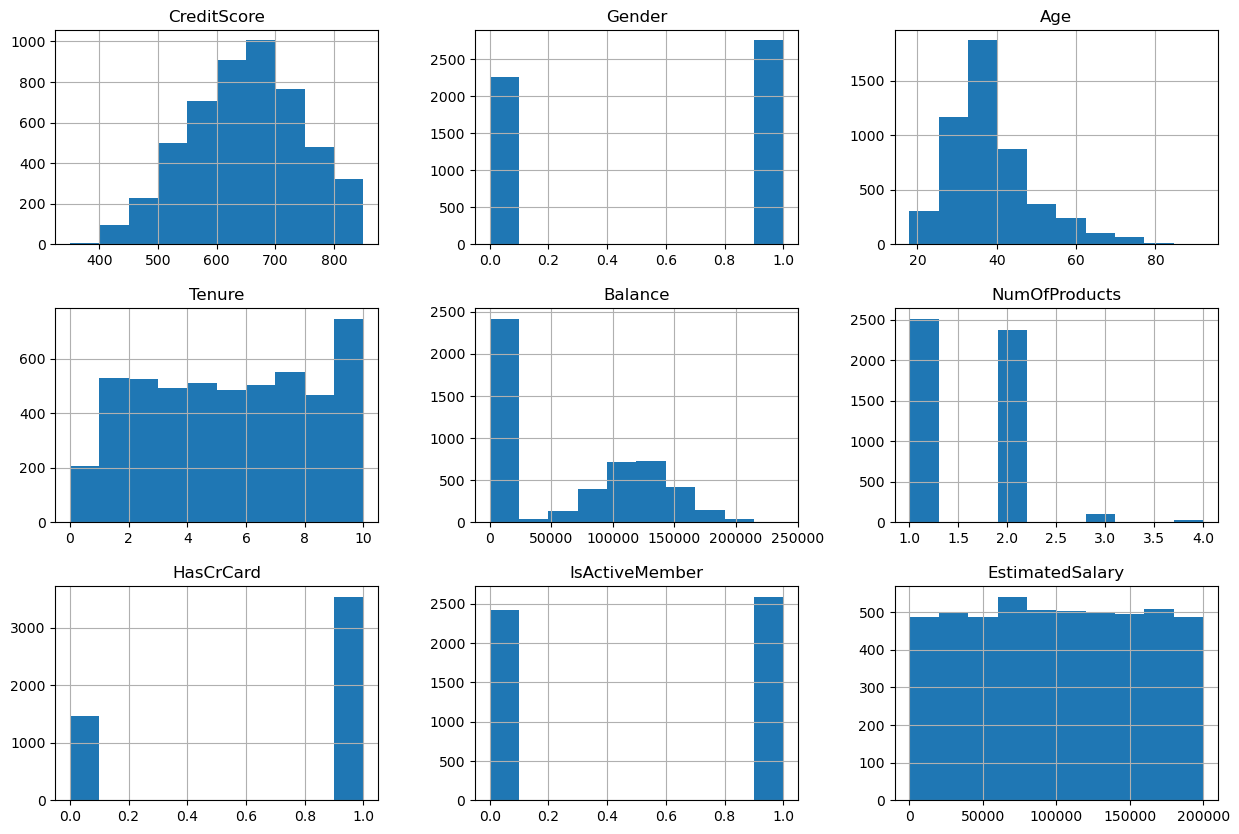

In [4]:
df.hist(figsize=(15,10))

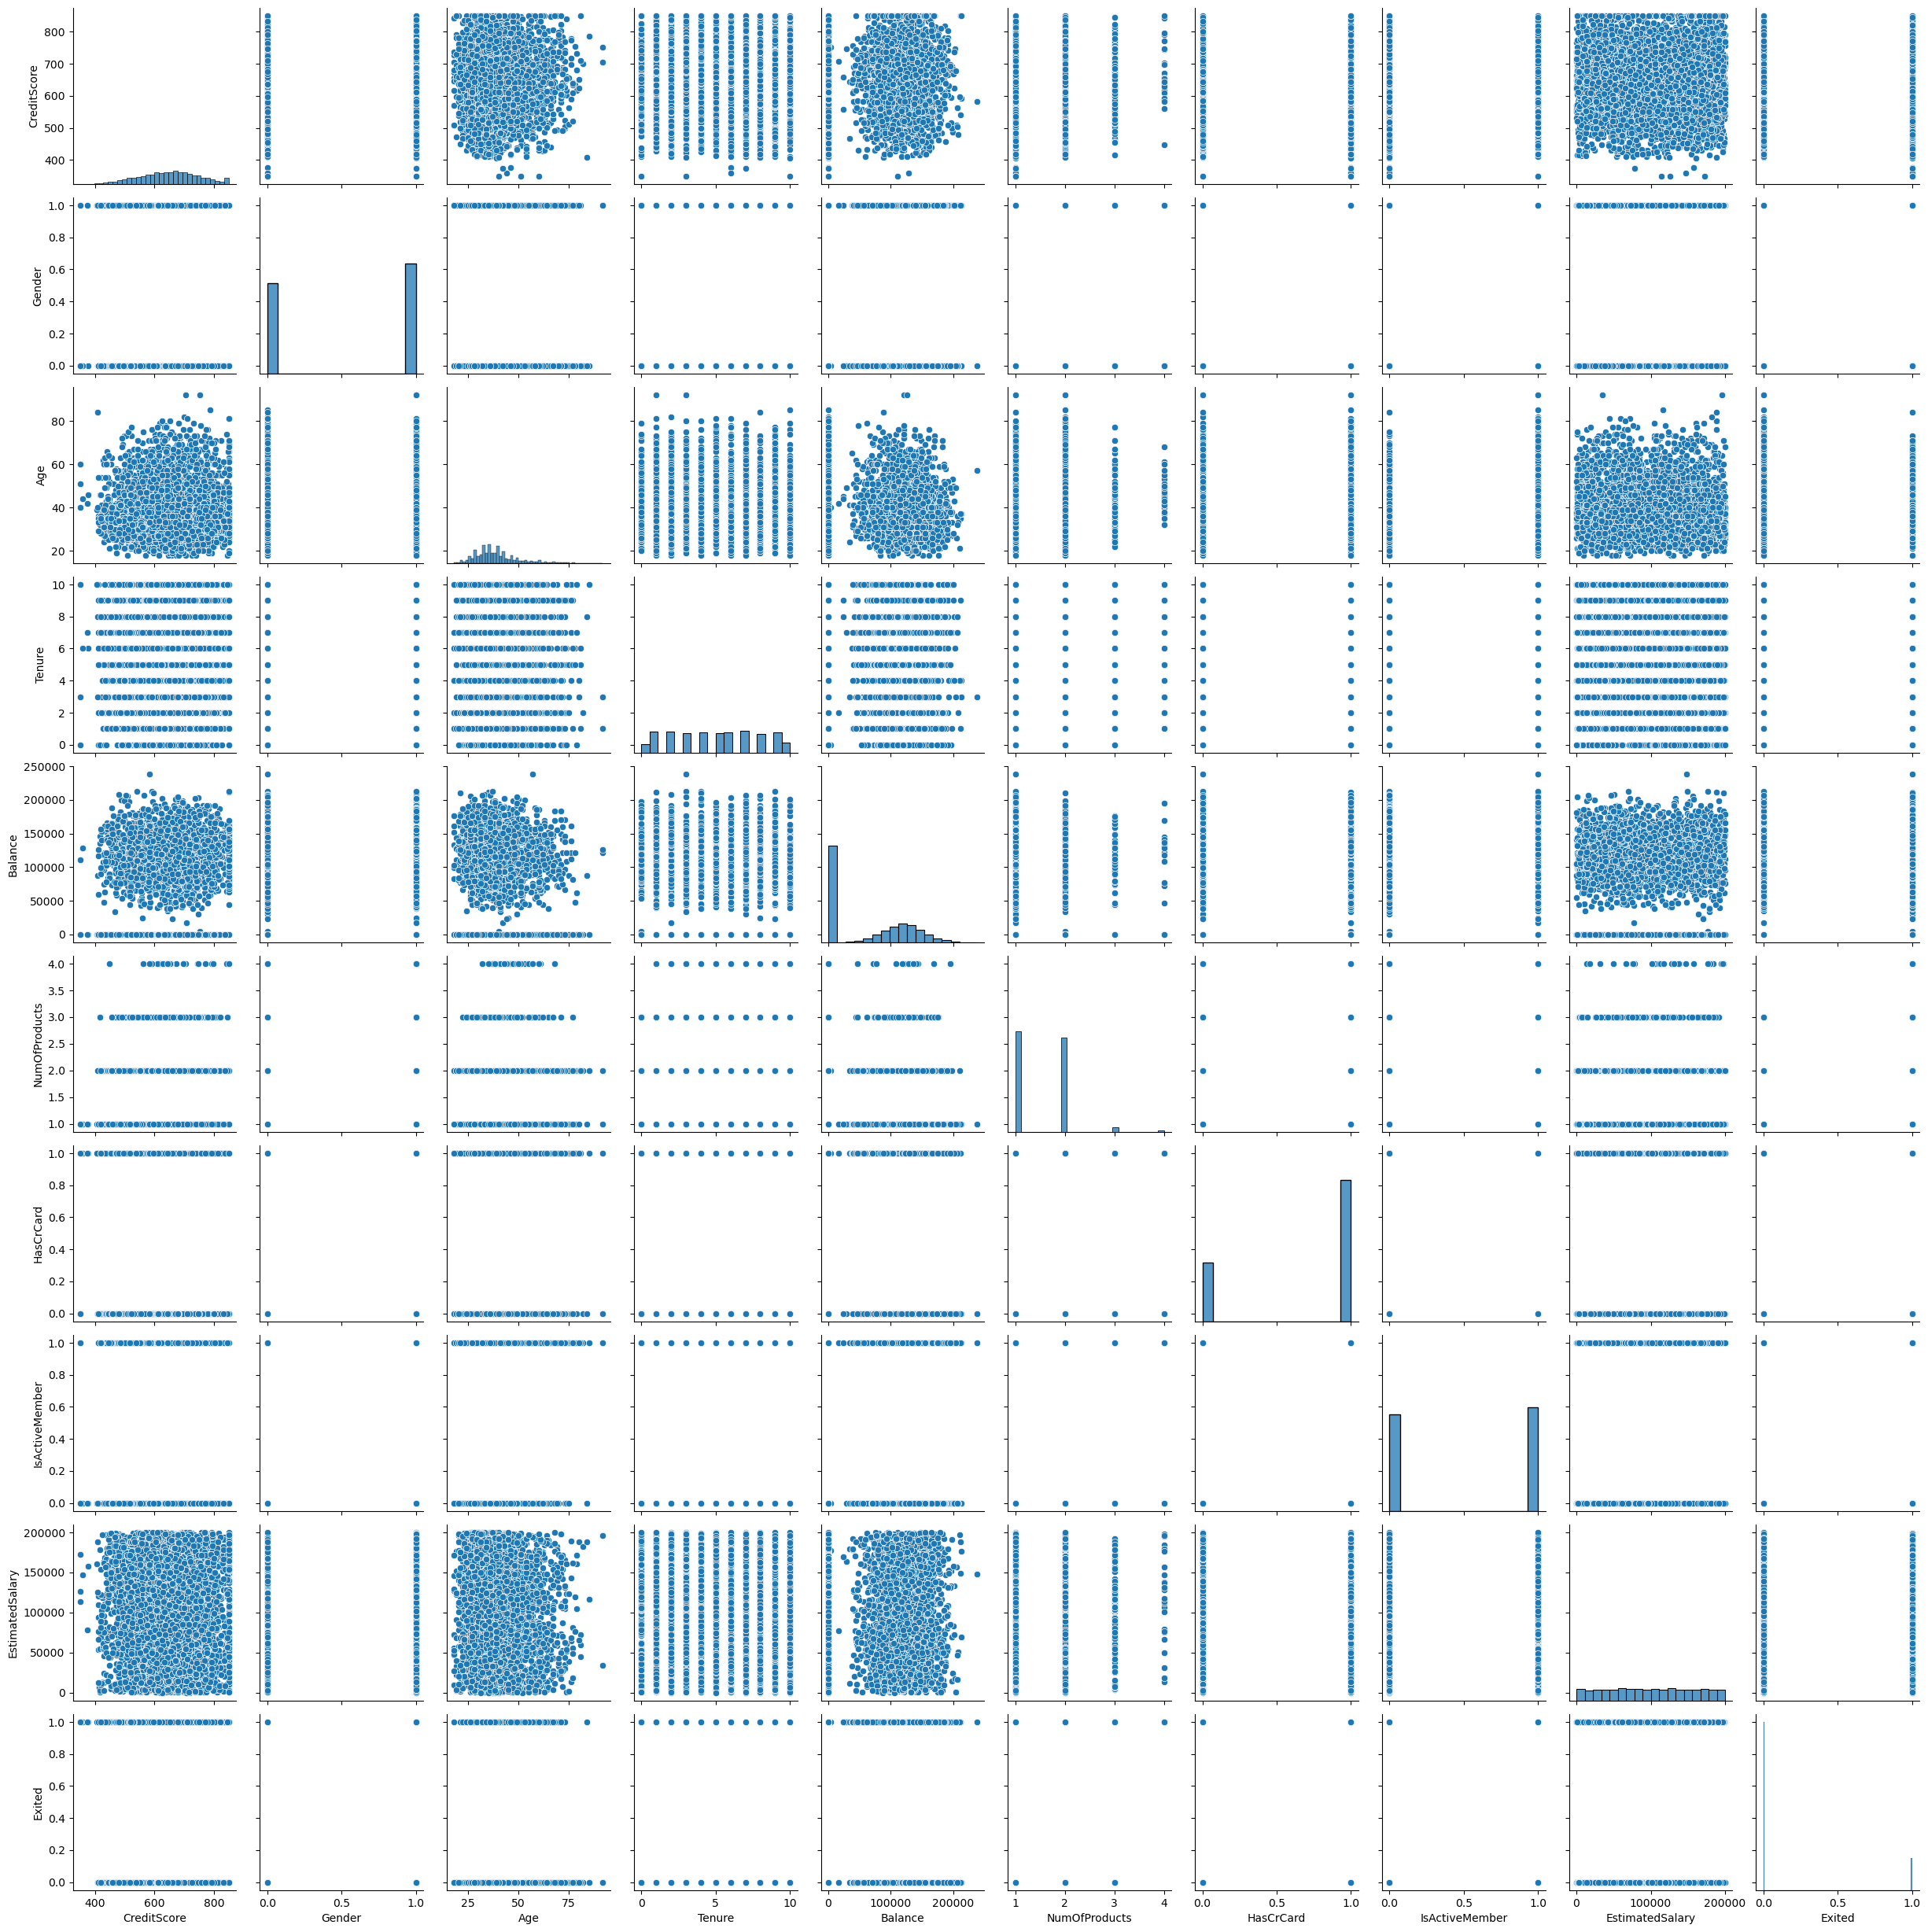

In [5]:
sns.pairplot(df)

In [6]:
df.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,5014.000000,5014.000000,5014.000000,5014.000000,5014.000000,5014.000000,5014.000000,5014.000000,5014.000000
mean,649.668329,0.549063,38.511767,5.004587,62092.636516,1.530913,0.706621,0.516753,99899.180814
std,97.016799,0.497637,10.469459,2.888475,64133.565524,0.570347,0.455356,0.499769,57336.289016
min,350.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,90.070000
25%,582.000000,0.000000,31.000000,2.000000,0.000000,1.000000,0.000000,0.000000,51399.190000
50%,653.000000,1.000000,37.000000,5.000000,62153.500000,1.000000,1.000000,1.000000,99132.310000
75%,717.000000,1.000000,43.000000,7.000000,121444.877500,2.000000,1.000000,1.000000,149295.360000
max,850.000000,1.000000,92.000000,10.000000,238387.560000,4.000000,1.000000,1.000000,199929.170000


In [7]:
print(f'Missing Values per columns: \n{df.isna().sum()}')

Missing Values per columns: 
CreditScore        0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [32]:
target = 'Exited'
X = df.drop([target],axis=1)
y = df[target]

df.shape

(5014, 10)

In [21]:
y.value_counts()

Exited
False    4204
True      810
Name: count, dtype: int64

<Axes: xlabel='Exited'>

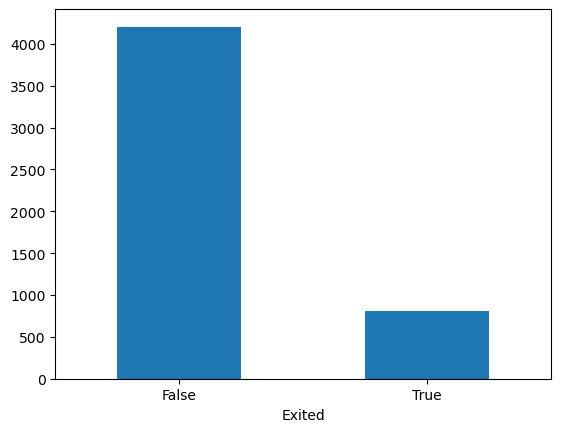

In [10]:
y.value_counts().sort_index().plot(kind='bar',rot=0)

In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier,RandomForestClassifier

model_lbls = [
    'dt',
    'nb',
    'lp',
    'knn',
    'adb',
    'rf'
]

param_dt = [{'max_depth':[*range(1,20)],'class_weight':[None,'balanced']}]
param_nb = [{'var_smoothing':[10**exp for exp in range(-3,-12,-1)]}]
param_lp = [{'early_stopping':[True,False],'class_weight':[None,'balanced']}]
param_knn = [{'n_neighbors':[*range(2,7)]}]
param_adb = [{'n_estimators':[*range(10,51,10)],'learning_rate':[0.5,0.75,1,1.25,1.5]}]
param_rf = [{'n_estimators':[*range(10,30,4)],'max_depth':[*range(4,30,4)],'class_weight':[None,'balanced']}]

models = {
    'dt': {
        'name': 'Decision Tree Classifier',
        'estimator': DecisionTreeClassifier(random_state=randomState),
        'param': param_dt,
    },
    'nb': {
        'name': 'Gaussian Native Bayers',
        'estimator': GaussianNB(),
        'param': param_nb,
    },
    'lp': {
        'name': 'Linear Perceptron',
        'estimator': Perceptron(random_state=randomState),
        'param': param_lp,
    },
    'knn': {
        'name': 'K nearest neighbors',
        'estimator': KNeighborsClassifier(),
        'param': param_knn,
    },
    'adb': {
        'name': 'Adaboost classifier',
        'estimator': AdaBoostClassifier(random_state=randomState),
        'param': param_adb,
    },
    'rf': {
        'name': 'Random Forest',
        'estimator': RandomForestClassifier(random_state=randomState),
        'param': param_rf
    }
}

In [18]:
scorings = ['accuracy','precision_macro','recall_macro','f1_macro']

In [25]:
y.shape

(5014,)

In [35]:
from sklearn.model_selection import train_test_split

Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,random_state=randomState,train_size=0.7)
print("Training on {} exemples".format(Xtrain.shape[0]))
print("Testing on {} exemples".format(Xtest.shape[0]))

Training on 3509 exemples
Testing on 1505 exemples


In [39]:
clfs = []
results = pd.DataFrame(columns=[
    'scoring',
    'model',
    'best_params',
    'accuracy',
    'precision_macro',
    'recall_macro',
    'f1_macro'
    ])

In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold

cv_spit = StratifiedKFold(n_splits=3)

for scoring in scorings:
    for m in model_lbls:
        clf = GridSearchCV(
            models[m]['estimator'],
            models[m]['param'],
            scoring=scoring,
            cv=cv_spit
        )
        clf.fit(Xtrain,ytrain)
        clfs.append(clf)
        y_predit = clf.predict(Xtest)
        cr = classification_report(ytest,y_predit,output_dict=True,zero_division=1)
        results.loc[len(results)] = [
            scoring,
            models[m]['name'],
            clf.best_params_,
            cr['accuracy'],
            cr['macro avg']['precision'],
            cr['macro avg']['recall'],
            cr['macro avg']['f1-score']
        ]

c:\Users\richy\anaconda3\envs\MLDM2526\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\richy\anaconda3\envs\MLDM2526\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\richy\anaconda3\envs\MLDM2526\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [46]:
for score in scorings:
    scoring_filter = score
    display(results[results.scoring==scoring_filter]\
            .sort_values(by=scoring_filter,ascending=False)\
            .style.format(precision=3)
            .set_caption('Result for scoring "{}"'.format(scoring_filter))
        )

,scoring,model,best_params,accuracy,precision_macro,recall_macro,f1_macro
8,accuracy,Random Forest,"{'class_weight': None, 'max_depth': 8, 'n_estimators': 14}",0.881,0.865,0.683,0.729
7,accuracy,Adaboost classifier,"{'learning_rate': 1.25, 'n_estimators': 50}",0.879,0.829,0.702,0.741
0,accuracy,Decision Tree Classifier,"{'class_weight': None, 'max_depth': 4}",0.872,0.800,0.700,0.734
1,accuracy,Decision Tree Classifier,"{'class_weight': None, 'max_depth': 4}",0.872,0.800,0.700,0.734
3,accuracy,Decision Tree Classifier,"{'class_weight': None, 'max_depth': 4}",0.872,0.800,0.700,0.734
2,accuracy,Gaussian Native Bayers,{'var_smoothing': 1e-11},0.847,0.811,0.574,0.588
4,accuracy,Gaussian Native Bayers,{'var_smoothing': 1e-11},0.847,0.811,0.574,0.588
5,accuracy,Linear Perceptron,"{'class_weight': None, 'early_stopping': True}",0.827,0.914,0.500,0.453
6,accuracy,K nearest neighbors,{'n_neighbors': 6},0.821,0.525,0.502,0.465


,scoring,model,best_params,accuracy,precision_macro,recall_macro,f1_macro
13,precision_macro,Adaboost classifier,"{'learning_rate': 0.75, 'n_estimators': 10}",0.833,0.916,0.517,0.488
14,precision_macro,Random Forest,"{'class_weight': None, 'max_depth': 4, 'n_estimators': 14}",0.867,0.902,0.621,0.658
10,precision_macro,Gaussian Native Bayers,{'var_smoothing': 1e-11},0.847,0.811,0.574,0.588
9,precision_macro,Decision Tree Classifier,"{'class_weight': None, 'max_depth': 4}",0.872,0.800,0.700,0.734
11,precision_macro,Linear Perceptron,"{'class_weight': 'balanced', 'early_stopping': True}",0.175,0.587,0.501,0.150
12,precision_macro,K nearest neighbors,{'n_neighbors': 6},0.821,0.525,0.502,0.465


,scoring,model,best_params,accuracy,precision_macro,recall_macro,f1_macro
15,recall_macro,Decision Tree Classifier,"{'class_weight': 'balanced', 'max_depth': 4}",0.724,0.649,0.744,0.651
20,recall_macro,Random Forest,"{'class_weight': 'balanced', 'max_depth': 4, 'n_estimators': 26}",0.759,0.658,0.737,0.672
19,recall_macro,Adaboost classifier,"{'learning_rate': 1.5, 'n_estimators': 10}",0.862,0.767,0.699,0.724
16,recall_macro,Gaussian Native Bayers,{'var_smoothing': 1e-11},0.847,0.811,0.574,0.588
18,recall_macro,K nearest neighbors,{'n_neighbors': 5},0.813,0.548,0.510,0.487
17,recall_macro,Linear Perceptron,"{'class_weight': 'balanced', 'early_stopping': False}",0.260,0.504,0.503,0.259


,scoring,model,best_params,accuracy,precision_macro,recall_macro,f1_macro
25,f1_macro,Adaboost classifier,"{'learning_rate': 1.25, 'n_estimators': 50}",0.879,0.829,0.702,0.741
26,f1_macro,Random Forest,"{'class_weight': 'balanced', 'max_depth': 8, 'n_estimators': 22}",0.837,0.721,0.751,0.734
21,f1_macro,Decision Tree Classifier,"{'class_weight': None, 'max_depth': 4}",0.872,0.800,0.700,0.734
22,f1_macro,Gaussian Native Bayers,{'var_smoothing': 1e-11},0.847,0.811,0.574,0.588
24,f1_macro,K nearest neighbors,{'n_neighbors': 3},0.786,0.542,0.522,0.519
23,f1_macro,Linear Perceptron,"{'class_weight': 'balanced', 'early_stopping': False}",0.260,0.504,0.503,0.259


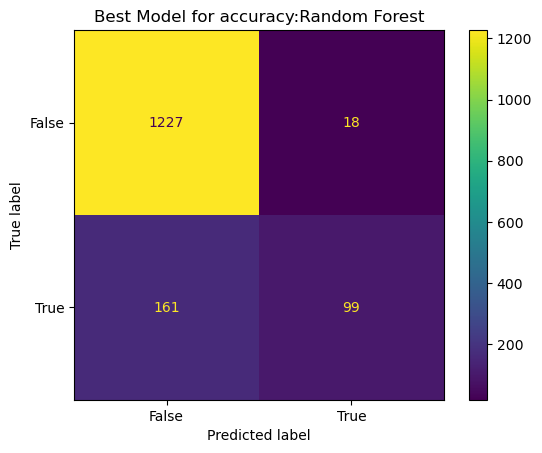

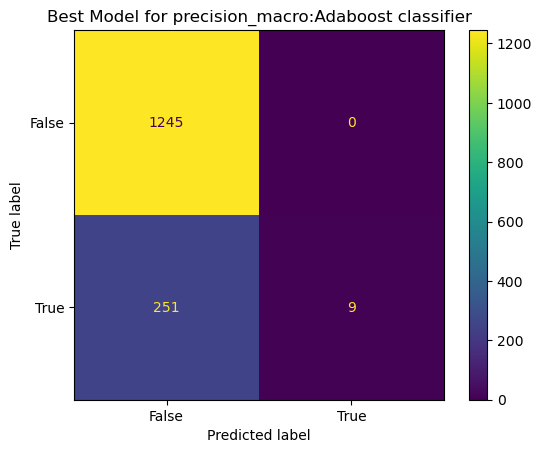

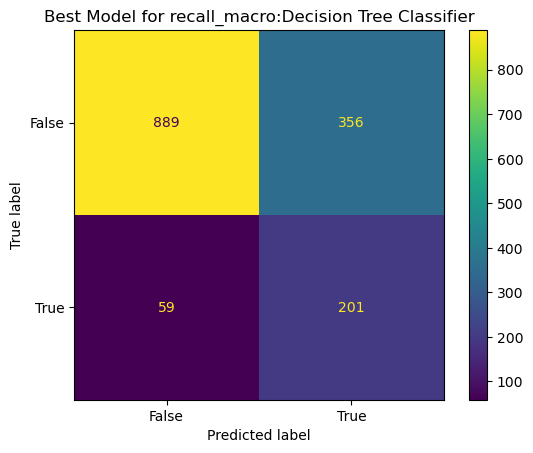

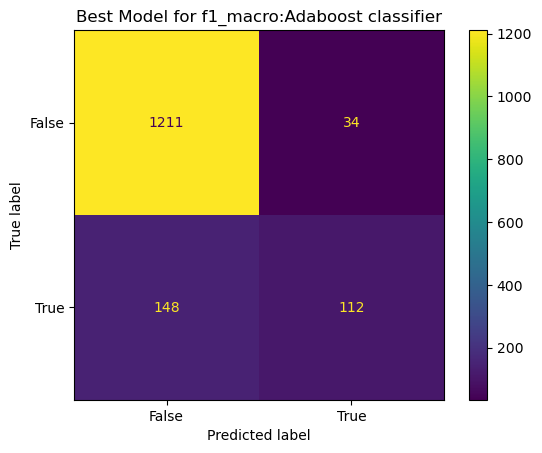

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay

for score in scorings:
    scoring_filter = score
    best_row = results.loc[results.scoring==score,score].idxmax(axis=0)
    disp = ConfusionMatrixDisplay.from_estimator(estimator=clfs[best_row],X=Xtest,y=ytest)
    disp.ax_.set_title("Best Model for {}:{}".format(score,results.at[best_row,'model']))
    

In [67]:
results.loc[results.scoring=='accuracy','accuracy'].idxmax(axis=0)

np.int64(8)

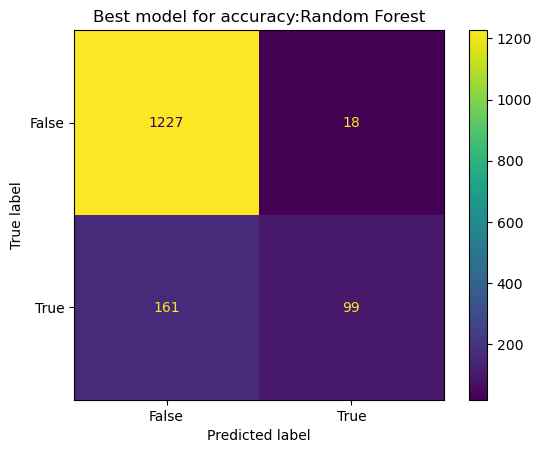

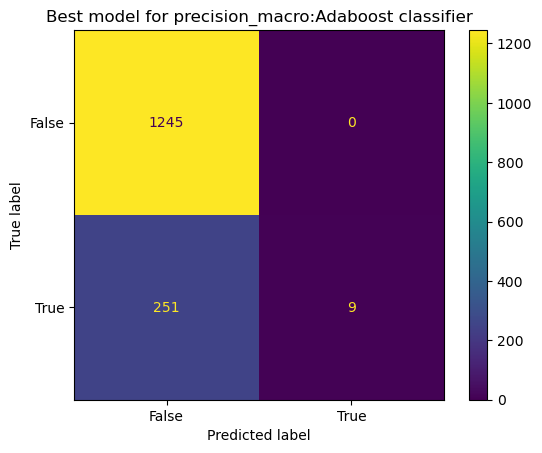

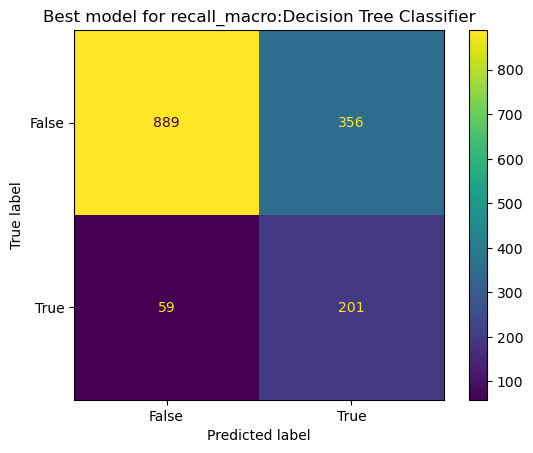

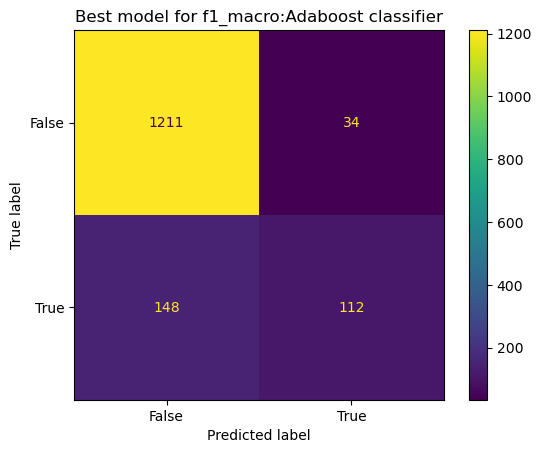

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay

for score in scorings:
    scoring_filter = score
    best_row = results.loc[results.scoring==scoring_filter,score].idxmax(axis=0)
    disp = ConfusionMatrixDisplay.from_estimator(
        estimator=clfs[best_row],
        X = Xtest,
        y= ytest
    )
    disp.ax_.set_title('Best model for {}:{}'.format(score,results.at[best_row,'model']))